# Parte 1: Filtros

1\) (30%) Investigar/Consultar y definir los siguientes filtros (la investigación debe contener la fórmula matemática, un ejemplo y su explicación):


A. Filtro de media (Santiago)

B. Filtro de mediana(Ricardo)

C. Filtro logarítmico(Santiago)

D. Filtro de cuadro normalizado(Ricardo)

E. Filtro gaussiano(Santiago)

F. Filtro Laplace(Ricardo)

G. Filtro Sobel(Santiago)

H. Filtro Canny(Ricardo)


2\) De los filtros definidos en el numeral describir ventajas y desventajas

3\) De los filtros definidos en el numeral 1 programar un ejemplo usando opencv ó Matlab por cada literal  

## 1. Investigación y Definición de Filtros

### A. Filtro de Media (Santiago)
Es el "borrador" básico. Se usa para suavizar la imagen promediando los colores de los píxeles vecinos.
* **Fórmula:** $g(x, y) = \frac{1}{M} \sum_{(s, t) \in S_{xy}} f(s, t)$
* **Explicación:** Se toma una pequeña ventana (kernel), se suman todos los valores de los píxeles dentro de ella y se divide por el total de píxeles.
* **Ejemplo:** Si una foto tiene granos pequeños de ruido, el filtro de media los mezcla con el fondo para que se noten menos.

### B. Filtro de Mediana (Ricardo)
El salvador contra el ruido tipo "sal y pimienta".
* **Fórmula:** $g(x, y) = \text{mediana} \{f(s, t) \mid (s, t) \in S_{xy}\}$
* **Explicación:** En lugar de promediar, ordena los valores de los píxeles vecinos y elige justo el que queda en el medio.
* **Ejemplo:** Si un píxel blanco (ruido) está rodeado de negros, la mediana elegirá el negro, eliminando el punto blanco por completo sin ensuciar el resto.

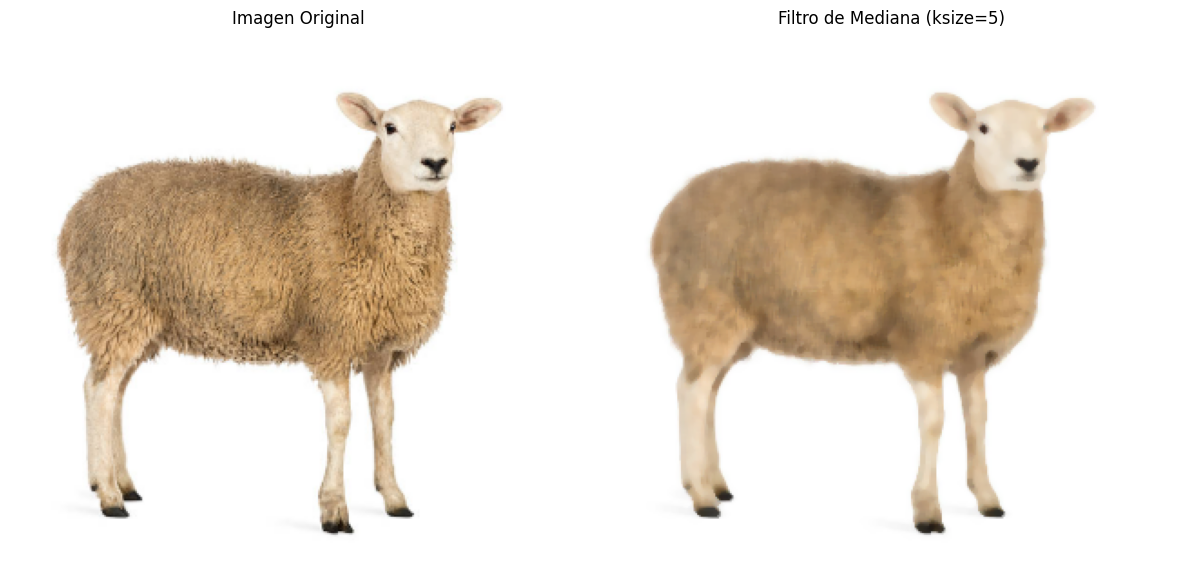

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('sheep.png')

# Verificar si la imagen se cargó correctamente
if img is None:
    print("Error: No se pudo cargar la imagen 'sheep.png'")
    exit()

# Convertir de BGR (OpenCV) a RGB (para matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aplicar filtro de mediana (tamaño del kernel: 5x5)
# El tamaño debe ser un número impar: 3, 5, 7, etc.
img_median = cv2.medianBlur(img_rgb, ksize=5)

# Mostrar las imágenes lado a lado
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_median)
plt.title('Filtro de Mediana (ksize=5)')
plt.axis('off')

plt.tight_layout()
plt.show()

### C. Filtro Logarítmico (Santiago)
Ideal para cuando la foto está "muy oscura" en algunas partes y no se ve nada.
* **Fórmula:** $g(x, y) = c \cdot \log(1 + f(x, y))$
* **Explicación:** Expande los valores oscuros y comprime los brillantes. Básicamente, le da luz a las sombras.
* **Ejemplo:** Útil para ver detalles en el fondo de una cueva o en fotos con mucha sombra.

### D. Filtro de Cuadro Normalizado (Ricardo)
Es como el de media, pero con esteroides de simplicidad.
* **Fórmula:** $K = \frac{1}{K_{w} \cdot K_{h}} \begin{bmatrix} 1 & 1 & \dots & 1 \\ \vdots & \vdots & \ddots & \vdots \\ 1 & 1 & \dots & 1 \end{bmatrix}$
* **Explicación:** Todos los píxeles del cuadro tienen exactamente el mismo peso. Se usa para desenfoques rápidos.
* **Ejemplo:** Cuando quieres que el fondo de una imagen se vea borroso de forma uniforme.

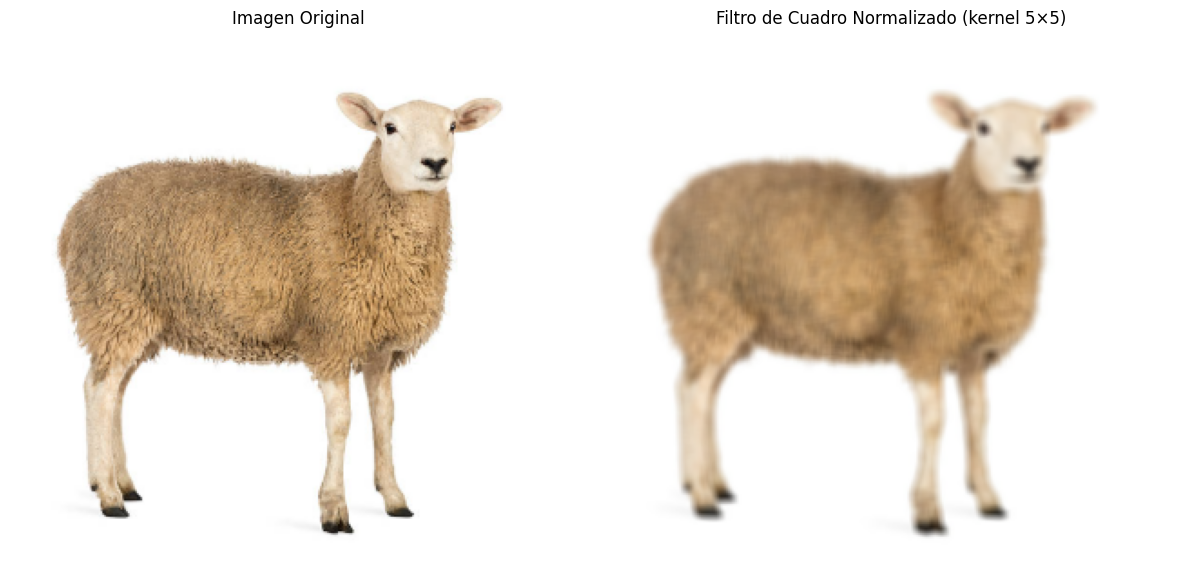

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('sheep.png')

# Verificar si la imagen se cargó correctamente
if img is None:
    print("Error: No se pudo cargar la imagen 'sheep.png'")
    exit()

# Convertir de BGR (OpenCV) a RGB (para matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aplicar filtro de cuadro normalizado (tamaño del kernel: 5x5)
# El tamaño puede ser par o impar, pero normalmente se usa impar
ksize = (5, 5)  # Ancho y alto del kernel
img_box = cv2.boxFilter(img_rgb, ddepth=-1, ksize=ksize, normalize=True)

# Opcional: Alternativa usando blur() que es equivalente
# img_box = cv2.blur(img_rgb, ksize=(5, 5))

# Mostrar las imágenes lado a lado
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_box)
plt.title(f'Filtro de Cuadro Normalizado (kernel {ksize[0]}×{ksize[1]})')
plt.axis('off')

plt.tight_layout()
plt.show()


### E. Filtro Gaussiano (Santiago)
El filtro de suavizado "premium". No desenfoca todo por igual, sino que cuida más el centro.
* **Fórmula:** $G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$
* **Explicación:** Los píxeles más cercanos al centro tienen más influencia que los de los bordes del kernel, siguiendo la campana de Gauss.
* **Ejemplo:** Es el desenfoque que ves en muchas apps de edición para que la piel se vea "suave" pero real.

### F. Filtro Laplace (Ricardo)
Un detective de bordes muy sensible.
* **Fórmula:** $\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$
* **Explicación:** Utiliza la segunda derivada para encontrar cambios bruscos de intensidad en cualquier dirección.
* **Ejemplo:** Resaltar las líneas finas de un dibujo o grabado.

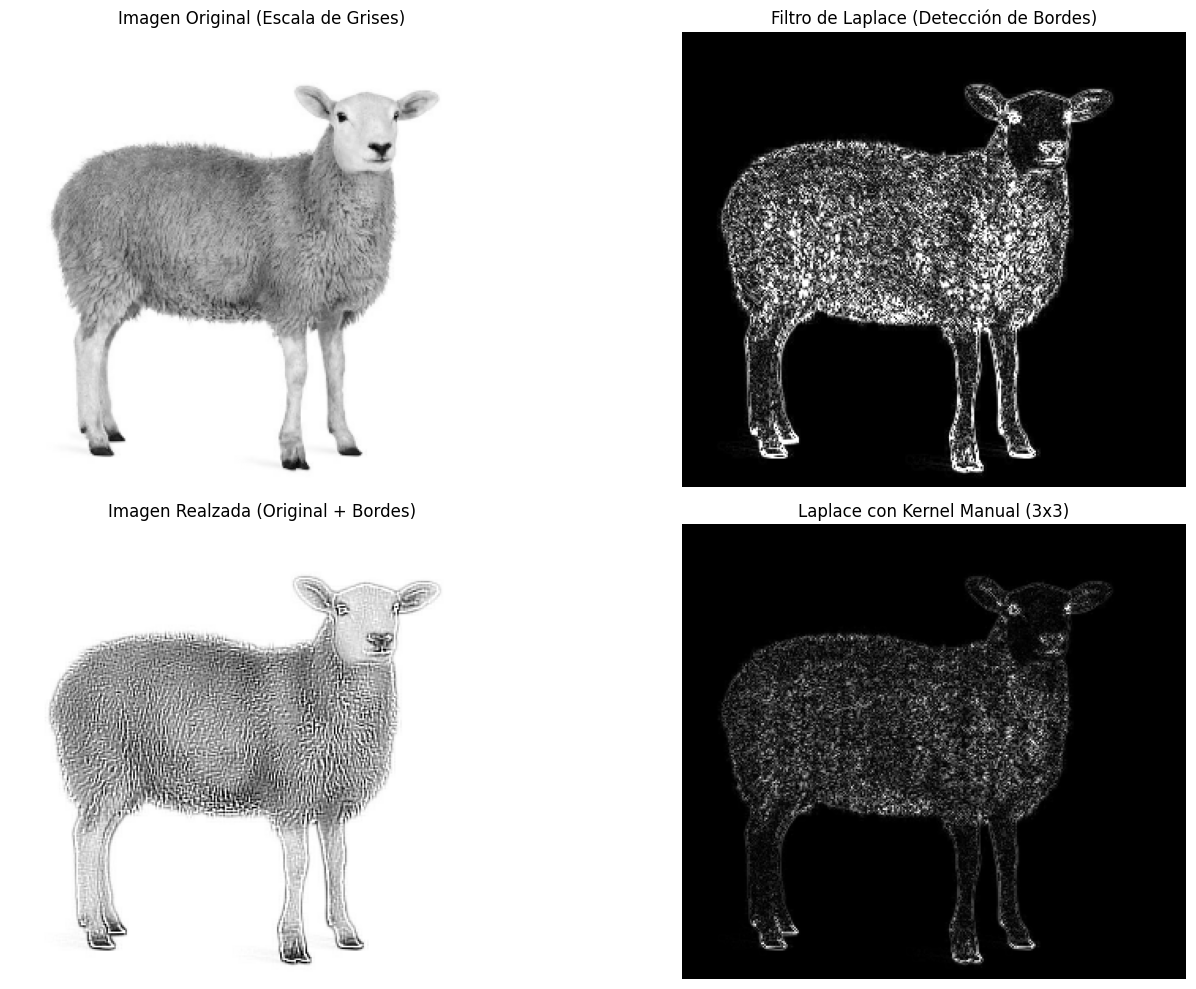

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('sheep.png')

# Verificar si la imagen se cargó correctamente
if img is None:
    print("Error: No se pudo cargar la imagen 'sheep.png'")
    exit()

# Convertir a escala de grises (el filtro Laplace normalmente se aplica a una banda)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Aplicar filtro de Laplace (detección de bordes)
# Método 1: Usando cv2.Laplacian() - RECOMENDADO
laplacian = cv2.Laplacian(img_gray, cv2.CV_64F, ksize=3)

# Convertir a uint8 para visualización (absoluto para mostrar bordes positivos y negativos)
laplacian_abs = cv2.convertScaleAbs(laplacian)

# Método 2: Aplicar Laplace manualmente con kernel personalizado
# Kernel de Laplace estándar (variante 1)
kernel_laplace = np.array([[0, 1, 0],
                           [1, -4, 1],
                           [0, 1, 0]], dtype=np.float32)

laplacian_manual = cv2.filter2D(img_gray.astype(np.float32), -1, kernel_laplace)
laplacian_manual_abs = cv2.convertScaleAbs(laplacian_manual)

# Mostrar las imágenes lado a lado
plt.figure(figsize=(15, 10))

# Imagen original en grises
plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original (Escala de Grises)')
plt.axis('off')

# Resultado de Laplace (bordes)
plt.subplot(2, 2, 2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Filtro de Laplace (Detección de Bordes)')
plt.axis('off')

# Imagen original con bordes superpuestos (opcional: realzar bordes)
img_enhanced = cv2.addWeighted(img_gray.astype(np.float32), 1.0, 
                                laplacian.astype(np.float32), 0.5, 0)
img_enhanced = np.clip(img_enhanced, 0, 255).astype(np.uint8)

plt.subplot(2, 2, 3)
plt.imshow(img_enhanced, cmap='gray')
plt.title('Imagen Realzada (Original + Bordes)')
plt.axis('off')

# Diferencia entre kernels (para mostrar las variantes)
plt.subplot(2, 2, 4)
plt.imshow(laplacian_manual_abs, cmap='gray')
plt.title('Laplace con Kernel Manual (3x3)')
plt.axis('off')

plt.tight_layout()
plt.show()


# Mostrar información adicional
#print(f"Tamaño del kernel: 3x3")
#print(f"Rango de valores de Laplace: [{laplacian.min():.2f}, {laplacian.max():.2f}]")

### G. Filtro Sobel (Santiago)
Resalta bordes separando las líneas horizontales de las verticales.
* **Fórmula:** $G = \sqrt{G_x^2 + G_y^2}$
* **Explicación:** Calcula la variación de color (gradiente) en los ejes X y Y.
* **Ejemplo:** Detectar el contorno de una puerta o el horizonte en una foto.

### H. Filtro Canny (Ricardo)
El "pro" de los detectores de bordes. Es más un algoritmo que un solo filtro.
* **Proceso:** Suavizado -> Gradiente -> Eliminación de falsos positivos -> Unión de bordes.
* **Explicación:** Busca bordes perfectos, delgados y continuos, ignorando el ruido que confunde a otros filtros.
* **Ejemplo:** Escanear un documento y querer extraer solo el contorno de las letras.


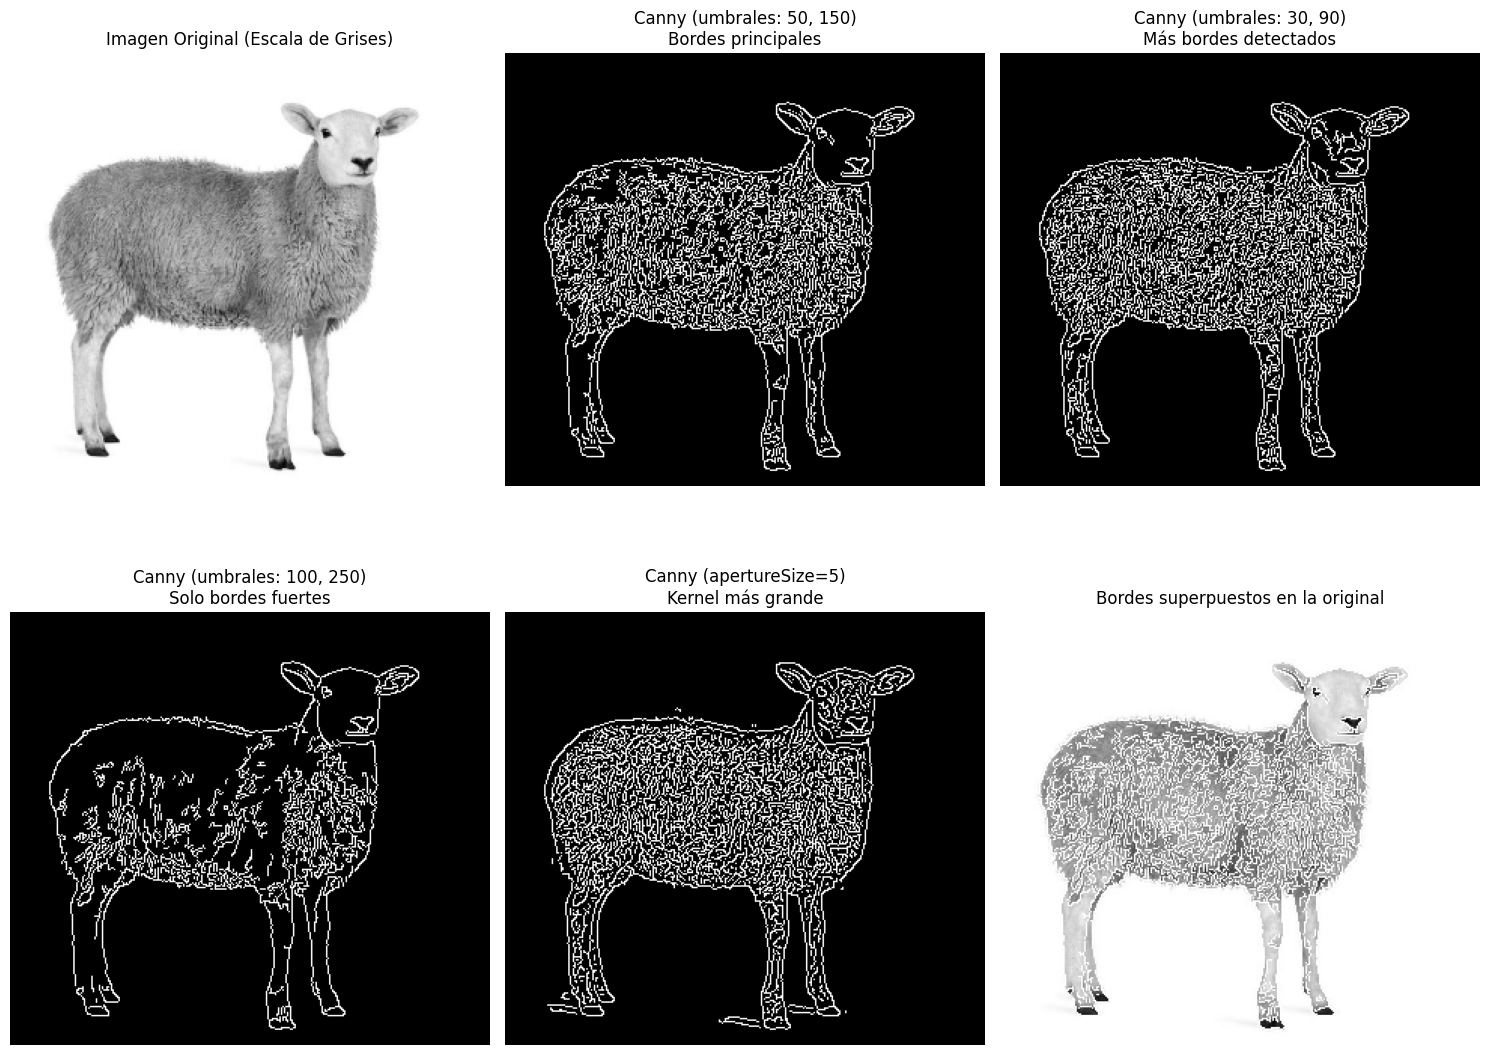

=== Información del filtro Canny ===
Forma de la imagen: (288, 319)
Bordes detectados (conservador): 9275 píxeles
Bordes detectados (agresivo): 10359 píxeles
Bordes detectados (restrictivo): 5656 píxeles

Con suavizado previo: 2067 píxeles (menos ruido)


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('sheep.png')

# Verificar si la imagen se cargó correctamente
if img is None:
    print("Error: No se pudo cargar la imagen 'sheep.png'")
    exit()

# Convertir a escala de grises (Canny trabaja con una banda)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Aplicar filtro Canny con diferentes umbrales
# Método 1: Umbrales conservadores (bordes bien definidos)
edges_conservative = cv2.Canny(img_gray, threshold1=50, threshold2=150)

# Método 2: Umbrales agresivos (más bordes, incluye bordes débiles)
edges_aggressive = cv2.Canny(img_gray, threshold1=30, threshold2=90)

# Método 3: Umbrales restrictivos (solo bordes muy pronunciados)
edges_restrictive = cv2.Canny(img_gray, threshold1=100, threshold2=250)

# Método 4: Canny con tamaño de kernel personalizado (Aperture size)
edges_aperture = cv2.Canny(img_gray, threshold1=50, threshold2=150, apertureSize=5)

# Visualización comparativa
plt.figure(figsize=(15, 12))

# Original en grises
plt.subplot(2, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original (Escala de Grises)')
plt.axis('off')

# Canny conservador
plt.subplot(2, 3, 2)
plt.imshow(edges_conservative, cmap='gray')
plt.title('Canny (umbrales: 50, 150)\nBordes principales')
plt.axis('off')

# Canny agresivo
plt.subplot(2, 3, 3)
plt.imshow(edges_aggressive, cmap='gray')
plt.title('Canny (umbrales: 30, 90)\nMás bordes detectados')
plt.axis('off')

# Canny restrictivo
plt.subplot(2, 3, 4)
plt.imshow(edges_restrictive, cmap='gray')
plt.title('Canny (umbrales: 100, 250)\nSolo bordes fuertes')
plt.axis('off')

# Canny con apertureSize=5
plt.subplot(2, 3, 5)
plt.imshow(edges_aperture, cmap='gray')
plt.title('Canny (apertureSize=5)\nKernel más grande')
plt.axis('off')

# Sobrepintar bordes Canny sobre la imagen original
img_overlay = img_gray.copy()
img_overlay[edges_conservative > 0] = 255  # Bordes en blanco
plt.subplot(2, 3, 6)
plt.imshow(img_overlay, cmap='gray')
plt.title('Bordes superpuestos en la original')
plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar información útil
print("=== Información del filtro Canny ===")
print(f"Forma de la imagen: {img_gray.shape}")
print(f"Bordes detectados (conservador): {np.sum(edges_conservative > 0)} píxeles")
print(f"Bordes detectados (agresivo): {np.sum(edges_aggressive > 0)} píxeles")
print(f"Bordes detectados (restrictivo): {np.sum(edges_restrictive > 0)} píxeles")

# Ejemplo adicional: Canny con suavizado personalizado
img_smoothed = cv2.GaussianBlur(img_gray, (5, 5), 1.5)
edges_smoothed = cv2.Canny(img_smoothed, 50, 150)
print(f"\nCon suavizado previo: {np.sum(edges_smoothed > 0)} píxeles (menos ruido)")

## 2. Ventajas y Desventajas: Cara a Cara

| Filtro | Ventajas ✅ | Desventajas ❌ |
| :--- | :--- | :--- |
| **Media** | Súper rápido y fácil. | Deja la imagen muy borrosa. |
| **Mediana** | Borra puntos de ruido sin dañar bordes. | Tarda más en procesar (ordenar números). |
| **Logarítmico** | Recupera detalles ocultos en la oscuridad. | Puede hacer que la imagen se vea "lavada". |
| **Normalizado** | Sencillez máxima para desenfoques totales. | No es nada preciso con los detalles. |
| **Gaussiano** | Suavizado natural y elegante. | Requiere más matemáticas y CPU. |
| **Laplace** | Detecta bordes muy finos. | Se vuelve loco con el ruido (crea puntos donde no hay). |
| **Sobel** | Muy bueno para ver la dirección de los bordes. | Los bordes salen un poco gruesos. |
| **Canny** | El resultado es súper limpio y profesional. | Es el más complejo de configurar. |